In [30]:
!pip install torchinfo

In [31]:
# import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchsummary import summary

### Part 1: Load and explore data

In [32]:
transform = transforms.ToTensor()

In [33]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

In [34]:
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [35]:
print("Training dataset size:", len(cifar_train))
print("Test dataset size:", len(cifar_test))
print("Image shape:", cifar_train[0][0].shape)
print("Number of classes:", len(cifar_train.classes))
print("Class labels", cifar_train.classes)

Training dataset size: 50000
Test dataset size: 10000
Image shape: torch.Size([3, 32, 32])
Number of classes: 10
Class labels ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


The CIFAR10 dataset consists of 50,000 training imagesand 10,000 test images. Each image has a shape of(3, 32, 32), indicating that the images are 32×32 pixels with 3 color channels(RGB). The dataset contains 10 distinct classes, representing different object categories such as airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. This confirms that the task is a multi-class image classification problem, where the model must correctly classify each image into one of these 10 categories.

### Part 2: Preprocess the data

In [36]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

In [37]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

In [38]:
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [39]:
train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=64, shuffle=True)

In [40]:
test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=64, shuffle=False)

In [41]:
def imageshow(img):
  img = img/2+0.5
  img=img.permute(1,2,0)
  plt.imshow(img)
  plt.axis("off")

In [42]:
data_iter = iter(train_loader)
image, labels = next(data_iter)

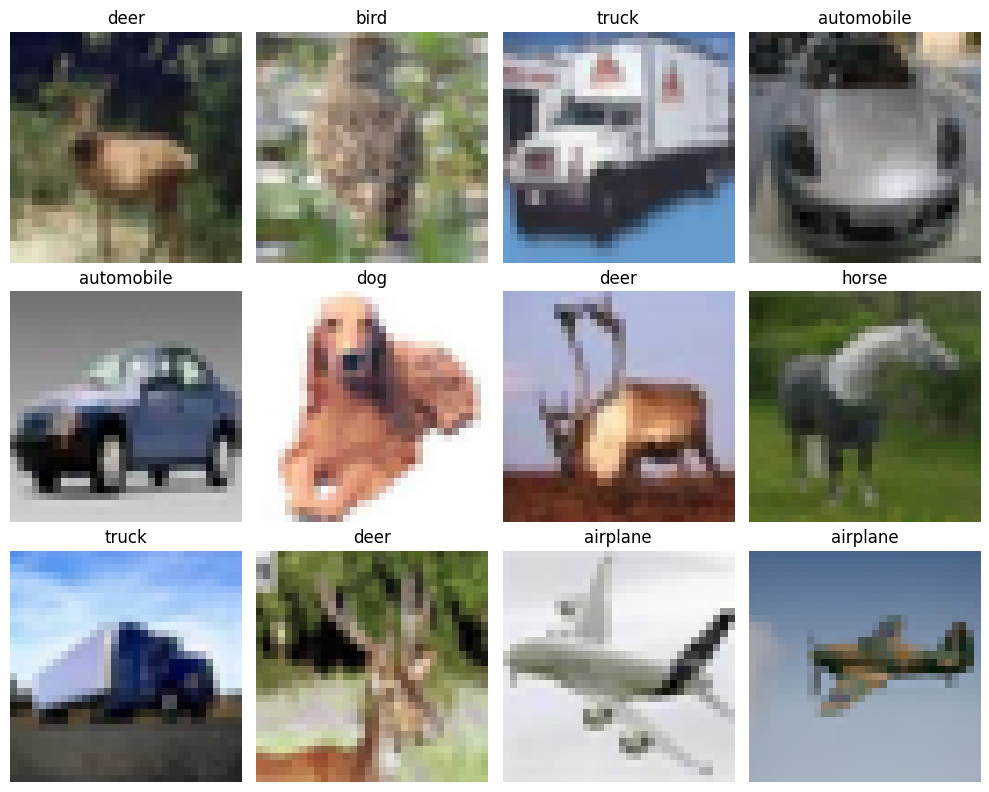

In [43]:
plt.figure(figsize=(10,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  imageshow(image[i])
  plt.title(cifar_train.classes[labels[i]])

plt.tight_layout()
plt.show()

The images were converted into tensors and normalized to improve training performance. The data was then divided into batches using a DataLoader, which helps with efficient computation and memory management. Training data was shuffled to improve generalization. A 3×4 grid of sample images from the training dataset was displayed to verify that the preprocessing steps were applied correctly. Each image is labelled with its corresponding class, confirming that the dataset is loaded and mapped properly. The images appear low resolution since CIFAR10 consists of 32×32 pixel images and some classes may look visually similar, which makes the classification task more challenging.

### Part 3: Build CNN model

In [44]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.fc_layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*4*4, 256),
        nn.ReLU(),
        nn.Linear(256,10)
    )

  def forward(self, x):
    x = self.conv_layers(x)
    x = self.fc_layers(x)
    return x


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [46]:
cnn_model = CNN().to(device)

In [47]:
summary(cnn_model, (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
         LeakyReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
              ReLU-8            [-1, 128, 8, 8]               0
         MaxPool2d-9            [-1, 128, 4, 4]               0
          Flatten-10                 [-1, 2048]               0
           Linear-11                  [-1, 256]         524,544
             ReLU-12                  [-1, 256]               0
           Linear-13                   [-1, 10]           2,570
Total params: 620,362
Trainable params:

The CNN model consists of three convolution layers followed by ReLU activation and max pooling layers. The convolutional layers gradually increase the number of feature maps from 32 to 64 and then to 128, allowing the model to learn complex image features. At the same time max pooling reduces the spatial dimensions from 32×32 to 16×16, then 8×8 and finally 4×4, which helps reduce computation while preserving important features.\
After feature extraction, the output is flattend into 2048 featuresand passed through fully connected layers for classification. The model contains a total of 620,362 trainable parameters.

In [49]:
# Train CNN model
train_loss = []
train_accuracy = []

criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

epochs = 5

for epoch in range(epochs):
  running_loss = 0.0
  correct = 0
  total = 0

  cnn_model.train()

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    cnn_optimizer.zero_grad()

    outputs = cnn_model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    cnn_optimizer.step()

    running_loss += loss.item()

    total += labels.size(0)
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()

  train_loss.append(running_loss/len(train_loader))
  train_accuracy.append(100*correct/total)
  print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {100*correct/total:.2f}")

Epoch [1/5], Training Loss: 0.5789, Train Accuracy: 79.60
Epoch [2/5], Training Loss: 0.5080, Train Accuracy: 82.23
Epoch [3/5], Training Loss: 0.4432, Train Accuracy: 84.44
Epoch [4/5], Training Loss: 0.3772, Train Accuracy: 86.78
Epoch [5/5], Training Loss: 0.3216, Train Accuracy: 88.73


The CNN model showed consistent improvement during training, with the training loss decreasing from 0.5789 to 0.3216 and training accuracy increasing from 79.6% to 88.73% over 5 epochs.

In [50]:
for epoch in range(epochs):
  test_loss = 0.0
  correct = 0
  total = 0

  cnn_model.eval()

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = cnn_model(images)
      loss = criterion(outputs, labels)

      test_loss += loss.item()
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(f"Test Accuracy for CNN Model: {100*correct/total:.2f}%")


Test Accuracy for CNN Model: 75.26%


### DenseNet Model

In [51]:
densenet_model = models.densenet121(weights = None)

num_features = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_features, 10)
densenet_model = densenet_model.to(device)

print(densenet_model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [52]:
total_params = sum(p.numel() for p in densenet_model.parameters())
trainable_params = sum(p.numel() for p in densenet_model.parameters() if p.requires_grad)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)
print("Final Classifier:", densenet_model.classifier)

Total Parameters: 6964106
Trainable Parameters: 6964106
Final Classifier: Linear(in_features=1024, out_features=10, bias=True)


##### Description of the model
The model used in this project is DenseNet-121, a convolutional neural network architecture that uses dense connections between layers. Unlike a traditional CNN, where each layer only receives input from the previous layer, densenet connects each layer to all preceding layers. This improves featuer reuse and helps gradients flow more effctively during training.\
The architecture begins with an initial convolutional layer followed by batch normalization, relu activation and max pooling. It then consists of multiple dense blocks, where each layer receives inputs from al earlier layers, allowing the network to reuse features instead of releaning them. Between dense blocks, transition layers are used to reduce the number of feature maps and downsample the spatial dimensions using 1×1 convolutions and average pooling. At the end of the network, a final fully connected(linear) layer is used for classification.

In this implementation, the classifier was modified to output 10 classes, corresponding to the CIFAR-10 dataset. The model has a total of 6,964,106 trainable parameters and all parameters are updated during training.

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(densenet_model.parameters(), lr=0.0005)

train_loss_d = []
train_accuracy_d = []

test_loss_d = []
test_accuracy_d = []

epochs = 5

for epoch in range(epochs):
  running_loss = 0.0
  correct = 0
  total = 0
  densenet_model.train()

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = densenet_model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    total += labels.size(0)
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()

  train_loss = running_loss/len(train_loader)
  train_accuracy = 100*correct/total

  train_loss_d.append(train_loss)
  train_accuracy_d.append(train_accuracy)

  densenet_model.eval()
  t_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = densenet_model(images)
      loss = criterion(outputs, labels)

      t_loss += loss.item()
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  test_loss = t_loss/len(test_loader)
  test_accuracy = 100*correct/total

  test_loss_d.append(test_loss)
  test_accuracy_d.append(test_accuracy)

  print(f"Epoch [{epoch+1}/{epochs}] Train Loss for DenseNet model: {train_loss:.4f} Train Accuracy for DenseNet Model: {train_accuracy},"
  f"Test Loss for DenseNet Model: {test_loss:.4f}, Test Accuracy for DenseNet Model: {test_accuracy:.2f}")

Epoch [1/5] Train Loss for DenseNet model: 0.4535 Train Accuracy for DenseNet Model: 84.204,Test Loss for DenseNet Model: 0.7888, Test Accuracy for DenseNet Model: 74.61
Epoch [2/5] Train Loss for DenseNet model: 0.3572 Train Accuracy for DenseNet Model: 87.408,Test Loss for DenseNet Model: 0.8075, Test Accuracy for DenseNet Model: 74.80
Epoch [3/5] Train Loss for DenseNet model: 0.2866 Train Accuracy for DenseNet Model: 89.858,Test Loss for DenseNet Model: 0.9083, Test Accuracy for DenseNet Model: 73.43
Epoch [4/5] Train Loss for DenseNet model: 0.2352 Train Accuracy for DenseNet Model: 91.7,Test Loss for DenseNet Model: 0.8888, Test Accuracy for DenseNet Model: 74.89
Epoch [5/5] Train Loss for DenseNet model: 0.2007 Train Accuracy for DenseNet Model: 92.89,Test Loss for DenseNet Model: 0.9272, Test Accuracy for DenseNet Model: 75.17


I used a batch size of 64 for both the training and test data loaders. The model was trained for 5 epochs. Adam optimizer was used with a learning rate of 0.0005 because it provides efficient and adaptive weight updates during training. CrossEntropyLoss was selected as the loss function since CIFAR10 is a multiclass classification problem.

The densenet model showed consistent improvement during training, with training loss decreaing from 0.4535 to 0.2007 and training accuracy increasing from 84.2% to 92.89% over 5 epochs. The test accuracy remained around 74%.

### Plot

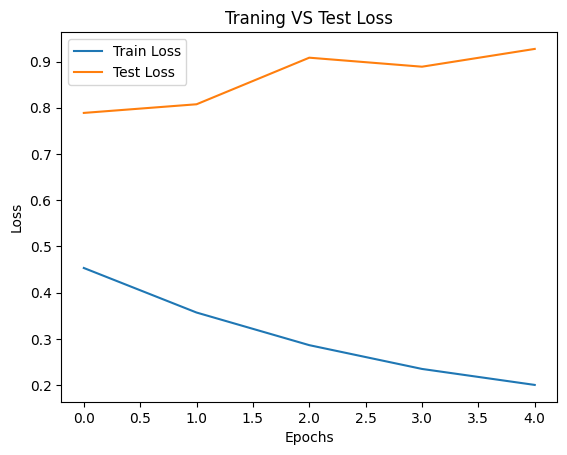

In [55]:
# Loss
plt.plot(train_loss_d, label="Train Loss")
plt.plot(test_loss_d, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Traning VS Test Loss")
plt.legend()
plt.show()

The training loss consistently decreased across epochs, indicating that the DenseNet modelwas learing effectively from the training data. However, the test loss gradually incresed, suggesting possible overfitting where the model becomes too specialized to the training data and performs less effectively on unseen test images.

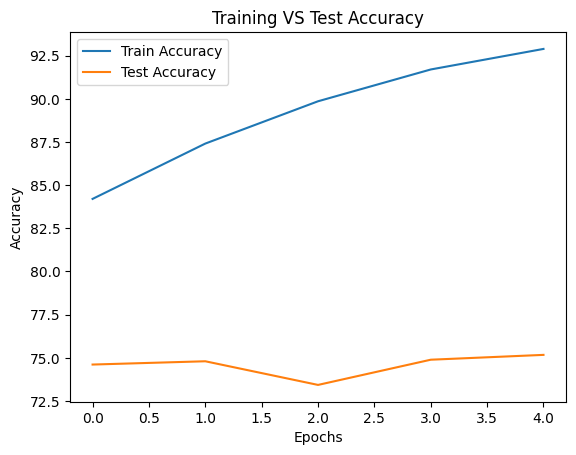

In [56]:
# Accuracy
plt.plot(train_accuracy_d, label="Train Accuracy")
plt.plot(test_accuracy_d, label = "Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training VS Test Accuracy")
plt.legend()
plt.show()

The training accuracy steadily increased from about 84%-93%, showing that the DenseNet model was learning the training data effectively overtime. However, the test accuracy remained relatively stable around 75%-76% and did not improve significantly across epochs. The gap between training and test accuracy suggests possible overfitting, where the model performs very well on training data but does not generalize equally well to unseen test images.

### Comparison between CNN and DenseNet

Compared to the CNN, DenseNet is a much deeper and more complex architecture that uses pretrained features and dense connections between layers. One interesting observation was that DenseNet achieved very high training accuracy quickly but the improvement in test accuracy was relatively small. In contrast, the simpler CNN achieved comparable test accuracy with fewer parameters and simpler architecture. This suggests that more complex pretrained models do not always guarantee significantly better performance on CIFAR10, especially when trained for only a few epochs.